# Meta Learners in EconML


**Treatment Effect** is the difference in outcomes caused by a treatment between a group that receives the treatment and one that does not.

In reality, we can only observe one outcome, either with treatment or without treatment, for each individual.

Three types of treatment effects:
* **Average Treatment Effect (ATE)**: This is the most common metric, measuring the effect across all customers.
* **Conditional Average Treatment Effect (CATE)**: This measures the effect within specific segments, such as males, females, or people in their 30s.
* **Individual Treatment Effect (ITE)**: This calculates the effect at the individual level.

Meta-learners are the **framework to predict these counterfactual values using machine learning**. By predicting and filling in the missing values(shown in red) with machine learning, we can estimate the Individual Treatment Effect (ITE).

In [1]:
!pip install dowhy econml

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 59.7 MB/s  0:00:00 52.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 6.2 MB/s  0:00:0060.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 55.4 MB/s  0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.6/547.6 kB 25.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.1/935.1 kB 2.6 MB/s  0:00:0069.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 5.3 MB/s  0:00:004.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 8.2 MB/s  0:00:007.9 MB/s eta 0:00:01:01
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import dowhy
from dowhy import datasets
import matplotlib.pyplot as plt

# Avoiding unnecessary log messges and warnings
import logging
logging.getLogger("dowhy").setLevel(logging.WARNING)
import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore', category=DataConversionWarning)

/Users/hsianghung/anaconda3/envs/casual_ml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Lalonde Dataset

**Lalonde** dataset, derived from an employment program conducted by Lalonde in the 1970s. The program aimed to assist disadvantaged workers in the U.S. in securing long-term employment through job training.


* Treatment: The "treat" column indicates participation in the job training program (1 if participated, 0 otherwise).
* Outcome: The "re78" column represents real earnings in 1978.
* Feature: Other columns like "age", "educ", "black", "hisp", "married", "nodegr", "re74", and "re75" are confounders that affect both treatment and outcome.

In [3]:
# Load the data
data = dowhy.datasets.lalonde_dataset()
print(data.shape)
data.head()

(445, 12)


,treat,age,educ,black,hisp,married,nodegr,re74,re75,re78,u74,u75
0,False,23.0,10.0,1.0,0.0,0.0,1.0,0.0,0.0,0.00,1.0,1.0
1,False,26.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,12383.68,1.0,1.0
2,False,22.0,9.0,1.0,0.0,0.0,1.0,0.0,0.0,0.00,1.0,1.0
3,False,18.0,9.0,1.0,0.0,0.0,1.0,0.0,0.0,10740.08,1.0,1.0
4,False,45.0,11.0,1.0,0.0,0.0,1.0,0.0,0.0,11796.47,1.0,1.0


In [4]:
data['treat'].value_counts(normalize = True)

treat
False    0.58427
True     0.41573
Name: proportion, dtype: float64

## S Learner

"S" means a single model: one model, and treat = 0/1 is in feature column. This is known as the base learner, which could be any supervised algorithm like **XGBoost** or **Random Forest**.

“Y1” represents the outcome when the coupon is used, while “Y0” represents the outcome without the coupon.

![](./images/s_learner.png)

In [15]:
import xgboost as xgb

# Setting features and target variable
features = ['age', 'educ', 'black', 'hisp', 'married', 'nodegr', 're74', 're75', 'treat']

s_X = data[features]
s_y = data['re78']

# Training the model
model = xgb.XGBRegressor()
model.fit(s_X, s_y)

df = s_X.copy()

# Predicting sales if treated and not treated
df['earning_pred_treated'] = model.predict(data[features].assign(treat=1))
df['earning_pred_control'] = model.predict(data[features].assign(treat=0))

# Calculating ATE
df['treatment_effect'] = df['earning_pred_treated'] - df['earning_pred_control']
ATE = df['treatment_effect'].mean()

print(f"Average Treatment Effect: {ATE}")

Average Treatment Effect: 1307.775390625


## T learner

The “T” in T-learner stands for “two,” as it utilizes **TWO** separate machine learning models: 
* One model is trained to predict the outcomes for customers who receive the treatment (e.g., a coupon).
* The other predicts outcomes for customers who do not.


![](./images/T_learner.png)


In [17]:
# Splitting the data into treated and control groups
df_treated = data[data['treat'] == 1]
df_control = data[data['treat'] == 0]

features = ['age', 'educ', 'black', 'hisp', 'married', 'nodegr', 're74', 're75'] # "treat" is no longer in feature

# Training the model for the treated group
model_treated = xgb.XGBRegressor()
model_treated.fit(df_treated[features], df_treated['re78'])

# Training the model for the untreated group
model_control = xgb.XGBRegressor()
model_control.fit(df_control[features], df_control['re78'])

df = data.copy()

# Predicting sales
df['earning_pred_treated'] = model_treated.predict(data[features])
df['earning_pred_control'] = model_control.predict(data[features])

# Calculating ATE
df['treatment_effect'] = df['earning_pred_treated'] - df['earning_pred_control']
ATE = df['treatment_effect'].mean()

print(f"Average Treatment Effect: {ATE}")

Average Treatment Effect: 1837.649169921875


## Advanced Meta Learners: Double Machine Learning (DML)

Two powerful open-source libraries for Causal Machine Learning: 
* **EconML**: primarily developed by Microsoft, offers a broad range of algorithms and tools for various causal inference tasks.
* **CausalML**: developed by Uber, is specifically designed for uplift modeling and marketing use cases.

In the below example, we implemented **EconML** meta-learner:
* We will use LightGBM, a gradient boosting framework, to predict the outcome (earnings)
* Logistic regression to predict the treatment (participation in the job training program).

In [24]:
from dowhy import CausalModel
from sklearn.preprocessing import StandardScaler

# Set features and target
features = ['age', 'educ', 'black', 'hisp', 'married', 'nodegr', 're74', 're75']
X = data[features]
y = data['re78']
T = data['treat']

# Scale the features
scaler = StandardScaler()
data[features] = scaler.fit_transform(X) # need to rescale feature, otherwise logisticRegression shows warning

# Define the causal model using DoWhy
model = CausalModel(
    data=data,
    treatment='treat',
    outcome='re78',
    common_causes=features
)
# Identify the causal effect
estimand = model.identify_effect(proceed_when_unidentifiable=True)

In [25]:
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMRegressor

# Estimate the causal effect using DML
estimate = model.estimate_effect(
    identified_estimand=estimand,
    method_name='backdoor.econml.dml.LinearDML',
    target_units='ate',
    method_params={
        'init_params': {
            'model_y': LGBMRegressor(n_estimators=100, max_depth=3, verbose=-1),
            'model_t': LogisticRegression(max_iter=1000),
            'discrete_treatment': True,
        },
        'fit_params': {}
    })

# Display the estimated causal effect
print(f"Estimated Average Treatment Effect (ATE): {estimate.value}")

Estimated Average Treatment Effect (ATE): 1927.054196848269


### Refutation

To verify the robustness of our causal model, we apply refutation methods. In causal inference, it is crucial to check whether the assumed causal graph is robust. 

We will use two methods: **Random Common Cause** and **Placebo Treatment**.

In [26]:
refutation_methods = [
    "random_common_cause",
    "placebo_treatment_refuter"
]

for method in refutation_methods:
    result = model.refute_estimate(estimand, estimate, method_name=method)
    print(result)

Refute: Add a random common cause
Estimated effect:1927.054196848269
New effect:1814.1687032699626
p value:0.74

Refute: Use a Placebo Treatment
Estimated effect:1927.054196848269
New effect:94.27851014533026
p value:0.98



## Visualize ATE


ATE means "Average Treatment Effect".

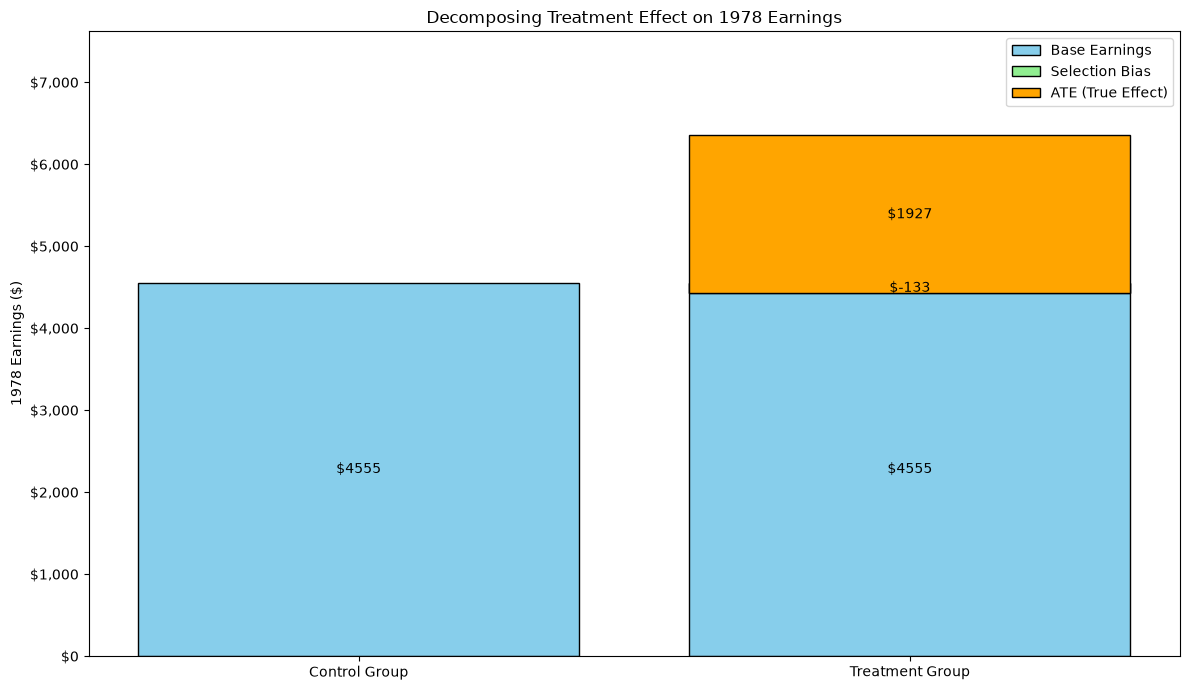

Control Group Average Earnings: $4554.80
Treatment Group Average Earnings: $6349.14
Average Treatment Effect (ATE): $1927.05
Selection Bias: $-132.71


In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate necessary data
control_earnings = data[data['treat'] == 0]['re78'].mean()
treatment_earnings = data[data['treat'] == 1]['re78'].mean()
ate = estimate.value

# Calculate selection bias
selection_bias = treatment_earnings - control_earnings - ate

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Create bars for control group and treatment group
ax.bar('Control Group', control_earnings, color='skyblue', edgecolor='black', label='Base Earnings')
ax.bar('Treatment Group', control_earnings, color='skyblue', edgecolor='black')

# Stack bars for selection bias and ATE
ax.bar('Treatment Group', selection_bias, bottom=control_earnings, color='lightgreen', edgecolor='black', label='Selection Bias')
ax.bar('Treatment Group', ate, bottom=control_earnings + selection_bias, color='orange', edgecolor='black', label='ATE (True Effect)')

# Add text labels
ax.text(0, control_earnings / 2, f'${control_earnings:.0f}', ha='center', va='center', color='black', fontsize=10)
ax.text(1, control_earnings / 2, f'${control_earnings:.0f}', ha='center', va='center', color='black', fontsize=10)
ax.text(1, control_earnings + selection_bias / 2, f'${selection_bias:.0f}', ha='center', va='center', color='black', fontsize=10)
ax.text(1, control_earnings + selection_bias + ate / 2, f'${ate:.0f}', ha='center', va='center', color='black', fontsize=10)

# Customize the plot
ax.set_ylim(0, treatment_earnings * 1.2)
ax.set_ylabel('1978 Earnings ($)')
ax.set_title('Decomposing Treatment Effect on 1978 Earnings')

# Add legend
ax.legend()

# Set Y-axis format
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '${:,.0f}'.format(y)))

plt.tight_layout()
plt.show()

# Output results
print(f"Control Group Average Earnings: ${control_earnings:.2f}")
print(f"Treatment Group Average Earnings: ${treatment_earnings:.2f}")
print(f"Average Treatment Effect (ATE): ${ate:.2f}")
print(f"Selection Bias: ${selection_bias:.2f}")